In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [2]:
from matplotlib import font_manager

font_dirs = ['/home/shenm19/arial-font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'

In [3]:
df1 = pd.read_csv('experiment_metrics_fully_parallel/default1.csv')
df1['Category'] = 'No augmentation'

df2 = pd.read_csv('experiment_metrics_fully_parallel/aug.csv')
df2['Category'] = 'Augmentation'

print(df1.columns)

Index(['val/total_mse', 'train/grad_norm', 'train/forces_magnitude_error',
       'train/lr', 'train/epoch', 'train/energy_mae', '_timestamp',
       'val/forces_mae', 'val/energy_mse', 'train/forces_mse',
       'train/energy_rmse', 'train/energy_forces_within_threshold',
       'val/forces_rmse', 'val/energy_mae', 'train/energy_mse',
       'val/energy_rmse', 'val/forces_cosine_similarity',
       'train/forces_cosine_similarity', 'train/step',
       'val/pct_loss_from_equiv_error', '_runtime', 'train/forces_mae',
       'val/loss', 'val/mean_pred_error', 'val/epoch',
       'val/energy_forces_within_threshold', 'train/loss', 'val/forces_mse',
       'val/forces_magnitude_error', 'train/forces_rmse', '_step',
       'val/equiv_error', 'Category'],
      dtype='object')


In [4]:
mdf = pd.concat([df1, df2], ignore_index=True)
print(mdf.columns)

Index(['val/total_mse', 'train/grad_norm', 'train/forces_magnitude_error',
       'train/lr', 'train/epoch', 'train/energy_mae', '_timestamp',
       'val/forces_mae', 'val/energy_mse', 'train/forces_mse',
       'train/energy_rmse', 'train/energy_forces_within_threshold',
       'val/forces_rmse', 'val/energy_mae', 'train/energy_mse',
       'val/energy_rmse', 'val/forces_cosine_similarity',
       'train/forces_cosine_similarity', 'train/step',
       'val/pct_loss_from_equiv_error', '_runtime', 'train/forces_mae',
       'val/loss', 'val/mean_pred_error', 'val/epoch',
       'val/energy_forces_within_threshold', 'train/loss', 'val/forces_mse',
       'val/forces_magnitude_error', 'train/forces_rmse', '_step',
       'val/equiv_error', 'Category', 'val/equiv_grad_norm',
       'val/grad_norm_ratio_equiv_over_mean', 'val/mean_pred_grad_norm'],
      dtype='object')


In [5]:
# adjust for finite-sample bias

cols = [
    'val/pct_loss_from_equiv_error',
    'val/equiv_error',
]
for col in cols:
    mdf[col] = mdf[col] * (10/9)

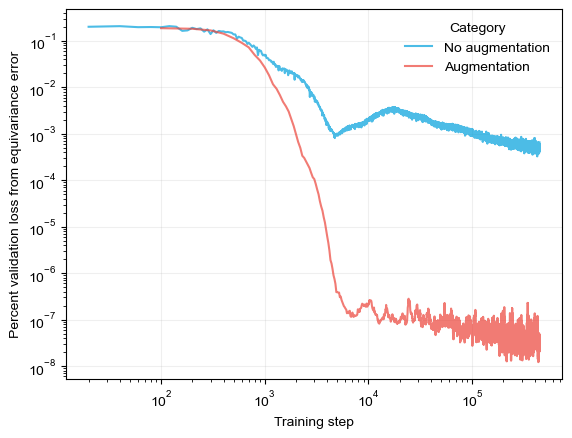

In [6]:
fig, ax = plt.subplots()
sns.lineplot(
    data=mdf,
    x='_step',
    y='val/pct_loss_from_equiv_error',
    hue = 'Category',
    palette = {
        'Augmentation': '#ec4339',
        'No augmentation': '#00a0dc',
    },
    errorbar = None,
    alpha=0.7,
    ax=ax,
)

plt.yscale('log')
plt.xscale('log')
plt.grid(alpha = 0.2)
plt.xlabel('Training step')
plt.ylabel('Percent validation loss from equivariance error')
plt.legend(frameon=False, title = 'Category')

# import matplotlib.ticker as mtick
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# plot_name = 'escaip-vary-train-size'

# import os
# os.makedirs('pdfs', exist_ok=True)
# os.makedirs('svgs', exist_ok=True)

# plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
# plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
# plt.savefig('svgs/' + plot_name + '.svg', transparent = True)
plt.show()
plt.close()

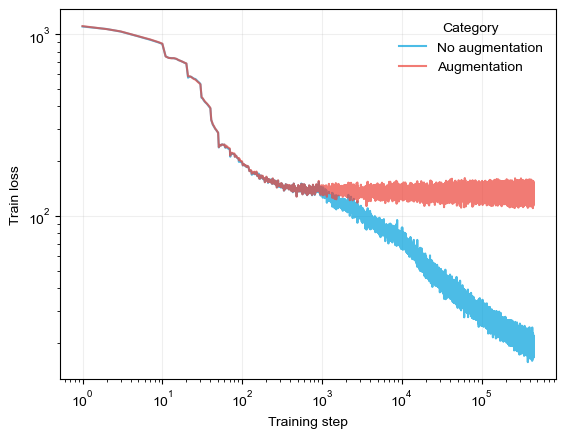

In [7]:
fig, ax = plt.subplots()
sns.lineplot(
    data=mdf,
    x='_step',
    y='train/loss',
    hue = 'Category',
    palette = {
        'Augmentation': '#ec4339',
        'No augmentation': '#00a0dc',
    },
    errorbar = None,
    alpha=0.7,
    ax=ax,
)

plt.yscale('log')
plt.xscale('log')
plt.grid(alpha = 0.2)
plt.xlabel('Training step')
plt.ylabel('Train loss')
plt.legend(frameon=False, title = 'Category')

# import matplotlib.ticker as mtick
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# plot_name = 'escaip-vary-train-size'

# import os
# os.makedirs('pdfs', exist_ok=True)
# os.makedirs('svgs', exist_ok=True)

# plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
# plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
# plt.savefig('svgs/' + plot_name + '.svg', transparent = True)
plt.show()
plt.close()

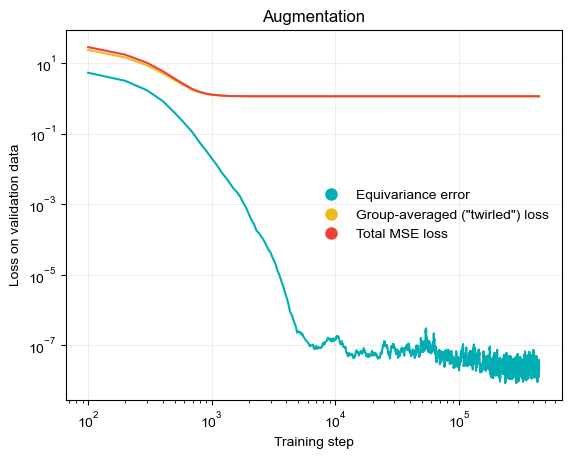

In [8]:
# Loss curves

df = mdf[mdf['Category'] == 'Augmentation']

sns.lineplot(
    data=df,
    x='_step',
    y='val/equiv_error',
    label = 'Equivariance error',
    color = '#00aeb3',
    errorbar = None,
)
sns.lineplot(
    data=df,
    x='_step',
    y='val/mean_pred_error',
    label = 'Group-averaged ("twirled") loss',
    color = '#efb920',
    errorbar = None,
)
sns.lineplot(
    data=df,
    x='_step',
    y='val/total_mse',
    color = '#ec4339',
    label = 'Total MSE loss',
    errorbar = None,
)

# sns.despine()
plt.yscale('log')
plt.xscale('log')
plt.grid(alpha = 0.2)


# Create custom Line2D objects to represent legend markers
import matplotlib.lines as mlines
equiv_handle = mlines.Line2D([], [], color='#00aeb3', marker='o', linestyle='None',
                          markersize=8, label='Equivariance error')
twirled_handle = mlines.Line2D([], [], color='#efb920', marker='o', linestyle='None',
                           markersize=8, label='Group-averaged ("twirled") loss')
total_handle = mlines.Line2D([], [], color='#ec4339', marker='o', linestyle='None',
                           markersize=8, label='Total MSE loss')
plt.legend(frameon=False, handles=[equiv_handle, twirled_handle, total_handle])
# plt.legend(frameon=False)

plt.title('Augmentation')
plt.xlabel('Training step')
plt.ylabel('Loss on validation data')

# plot_name = 'escaip-losscurves-5k'

# import os
# os.makedirs('pdfs', exist_ok=True)
# os.makedirs('svgs', exist_ok=True)

# plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
# plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
# plt.savefig('svgs/' + plot_name + '.svg', transparent = True)
plt.show()
plt.close()